In [1]:
import pyarrow  # must come FIRST
import pandas as pd

meteo_data_ = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\meteorological\meteo_data_20191001_20210101.parquet'
)
top_sub = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\module_performance\MR281_top_sub_20191001_20210101.parquet'
)
bottom_sub = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\module_performance\MR281_bottom_sub_20191001_20210101.parquet'
)
ape_corr = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\spectral\ ape_corr_20191001_20210101.parquet'
)
smr_corr = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\spectral\smr_corr_all_20191001_20210101.parquet'
)
topcell = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\model\ topcell_aligned.parquet'
)
bottom = pd.read_parquet(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\model\ bottom_aligned.parquet'
)
irradiance = pd.read_csv(
    '/Users/juanfelipe/Downloads/gaas-si-tandem-outdoor-deployment-data/data\model\ temp_modeldata_irradiance.csv'
)


In [2]:
dfs = {
    "ape_corr": ape_corr,
    "bottom": bottom,
    "bottom_sub": bottom_sub,
    "meteo_data_": meteo_data_,
    "smr_corr": smr_corr,
    "top_sub": top_sub,
    "topcell": topcell,
    "irradiance": irradiance
}

for name, data in dfs.items():
    print(f"{name}:")
    print(data.columns.tolist())
    print()

ape_corr:
['APE']

bottom:
['module', 'irrad_pre', 'irrad_post', 'irrad_mean', 'irrad_direct', 'temp_ambient_pre', 'temp_ambient_post', 'temp_ambient_mean', 'temp_module_pre', 'temp_module_post', 'temp_module_mean', 'temp_cell_mean', 'wind_speed', 'PWV', 'AM', 'APE', 'SMR', 'AOI', 'turbidity', 'AOD', 'voc', 'isc', 'pmp', 'vmp', 'imp']

bottom_sub:
['module', 'irrad_pre', 'irrad_post', 'irrad_mean', 'irrad_direct', 'temp_ambient_pre', 'temp_ambient_post', 'temp_ambient_mean', 'temp_module_pre', 'temp_module_post', 'temp_module_mean', 'temp_cell_mean', 'wind_speed', 'PWV', 'AM', 'APE', 'SMR', 'AOI', 'turbidity', 'AOD', 'voc', 'isc', 'pmp', 'vmp', 'imp']

meteo_data_:
['Global CMP22 (vent/cor) [W/m^2]', 'Direct sNIP [W/m^2]', 'Direct CHP1-1 [W/m^2]', 'Global 40-South CMP22 [W/m^2]', 'Global 40-South LI-200 [W/m^2]', 'Global 40-South CMP11 [W/m^2]', 'Global 40-South SP Lite2 [W/m^2]', 'Diffuse CM22-1 (vent/cor) [W/m^2]', 'Tower Dry Bulb Temp [deg C]', 'Deck Dry Bulb Temp [deg C]', 'Tower R

In [3]:
cols_module = [
    'irrad_mean', 'irrad_direct',
    'temp_ambient_mean', 'temp_module_mean', 'temp_cell_mean',
    'wind_speed', 'PWV', 'AM', 'APE', 'SMR', 'turbidity', 'AOD',
    'voc', 'isc', 'pmp', 'vmp', 'imp'
]

In [4]:
top_sub[cols_module].to_csv("top_sub.csv", index=True)
print(f"top_sub: {top_sub.shape[0]} filas")

bottom_sub[cols_module].to_csv("bottom_sub.csv", index=True)
print(f"bottom_sub: {bottom_sub.shape[0]} filas")

# --- APE ---

ape_corr.to_csv("ape_corr.csv", index=True)
print(f"ape_corr: {ape_corr.shape[0]} filas")

# --- SMR ---
smr_corr[['pre', 'post']].to_csv("smr_corr.csv", index=True)
print(f"smr_corr: {smr_corr.shape[0]} filas")

top_sub: 97362 filas
bottom_sub: 83153 filas
ape_corr: 319145 filas
smr_corr: 319145 filas


In [5]:
for nombre, df in dfs.items():
    print(f"\n=== {nombre} ===")
    print(f"Filas: {len(df)}")
    print(f"Índice: {df.index.dtype} | primeros 3: {df.index[:3].tolist()}")
    print(f"Columnas: {list(df.columns)[:5]}...")


=== ape_corr ===
Filas: 319145
Índice: datetime64[us] | primeros 3: [Timestamp('2019-10-04 07:19:00'), Timestamp('2019-10-04 07:20:00'), Timestamp('2019-10-04 07:21:00')]
Columnas: ['APE']...

=== bottom ===
Filas: 6461
Índice: datetime64[us] | primeros 3: [Timestamp('2019-10-23 11:07:07'), Timestamp('2019-10-23 11:09:07'), Timestamp('2019-10-23 11:11:08')]
Columnas: ['module', 'irrad_pre', 'irrad_post', 'irrad_mean', 'irrad_direct']...

=== bottom_sub ===
Filas: 83153
Índice: datetime64[us] | primeros 3: [Timestamp('2019-10-22 14:55:07'), Timestamp('2019-10-22 15:01:08'), Timestamp('2019-10-22 15:04:07')]
Columnas: ['module', 'irrad_pre', 'irrad_post', 'irrad_mean', 'irrad_direct']...

=== meteo_data_ ===
Filas: 660960
Índice: datetime64[us] | primeros 3: [Timestamp('2019-10-01 00:00:00'), Timestamp('2019-10-01 00:01:00'), Timestamp('2019-10-01 00:02:00')]
Columnas: ['Global CMP22 (vent/cor) [W/m^2]', 'Direct sNIP [W/m^2]', 'Direct CHP1-1 [W/m^2]', 'Global 40-South CMP22 [W/m^2]', 'G

In [6]:
base = meteo_data_.copy()

# Merge directo APE y SMR (mismo índice 1-min)
base = base.join(ape_corr[['APE']], how='left')
base = base.join(smr_corr[['pre', 'post']].rename(
    columns={'pre': 'SMR_pre', 'post': 'SMR_post'}), how='left')

# Columnas del módulo que nos interesan
cols_mod = ['irrad_mean', 'irrad_direct', 'temp_module_mean',
            'temp_cell_mean', 'PWV', 'AOD', 'turbidity',
            'voc', 'isc', 'pmp']

top_slim = top_sub[cols_mod].add_prefix('top_')
bot_slim = bottom_sub[cols_mod].add_prefix('bot_')

# Merge nearest para top y bottom (~2-6 min de resolución)
base = pd.merge_asof(base.sort_index(),
                     top_slim.sort_index(),
                     left_index=True, right_index=True,
                     tolerance=pd.Timedelta('6min'),
                     direction='nearest')

base = pd.merge_asof(base.sort_index(),
                     bot_slim.sort_index(),
                     left_index=True, right_index=True,
                     tolerance=pd.Timedelta('6min'),
                     direction='nearest')

# Feature clave: fracción difusa
base['diffuse_fraction'] = (
    base['Diffuse CM22-1 (vent/cor) [W/m^2]'] /
    base['Global CMP22 (vent/cor) [W/m^2]'].replace(0, float('nan'))
)

print(f"Shape final: {base.shape}")
print(f"\nNulos por columna (solo las que tienen):")
nulls = base.isnull().sum()
print(nulls[nulls > 0])

Shape final: (660960, 51)

Nulos por columna (solo las que tienen):
Global 40-South CMP22 [W/m^2]       132480
Global 40-South LI-200 [W/m^2]      528480
Global 40-South CMP11 [W/m^2]       528480
Global 40-South SP Lite2 [W/m^2]    132480
APE                                 341815
SMR_pre                             341815
SMR_post                            341815
top_irrad_mean                      475361
top_irrad_direct                    475361
top_temp_module_mean                475361
top_temp_cell_mean                  475361
top_PWV                             483715
top_AOD                             475361
top_turbidity                       475361
top_voc                             475361
top_isc                             475361
top_pmp                             475361
bot_irrad_mean                      484787
bot_irrad_direct                    484787
bot_temp_module_mean                484787
bot_temp_cell_mean                  484787
bot_PWV                      

In [7]:
base = base.drop(columns=[
    'Global 40-South LI-200 [W/m^2]',
    'Global 40-South CMP11 [W/m^2]',
    'Global 40-South SP Lite2 [W/m^2]',
])

# Solo horas de día (irradiancia global > 10 W/m²)
base_day = base[base['Global CMP22 (vent/cor) [W/m^2]'] > 10].copy()

print(f"Total:   {len(base):,} filas")
print(f"Diurno:  {len(base_day):,} filas")
print(f"Nulos restantes:")
nulls = base_day.isnull().sum()
print(nulls[nulls > 0])

Total:   660,960 filas
Diurno:  312,135 filas
Nulos restantes:
Global 40-South CMP22 [W/m^2]     53910
APE                                3252
SMR_pre                            3252
SMR_post                           3252
top_irrad_mean                   150757
top_irrad_direct                 150757
top_temp_module_mean             150757
top_temp_cell_mean               150757
top_PWV                          157826
top_AOD                          150757
top_turbidity                    150757
top_voc                          150757
top_isc                          150757
top_pmp                          150757
bot_irrad_mean                   158451
bot_irrad_direct                 158451
bot_temp_module_mean             158451
bot_temp_cell_mean               158451
bot_PWV                          165157
bot_AOD                          158451
bot_turbidity                    158451
bot_voc                          158451
bot_isc                          158451
bot_pmp          

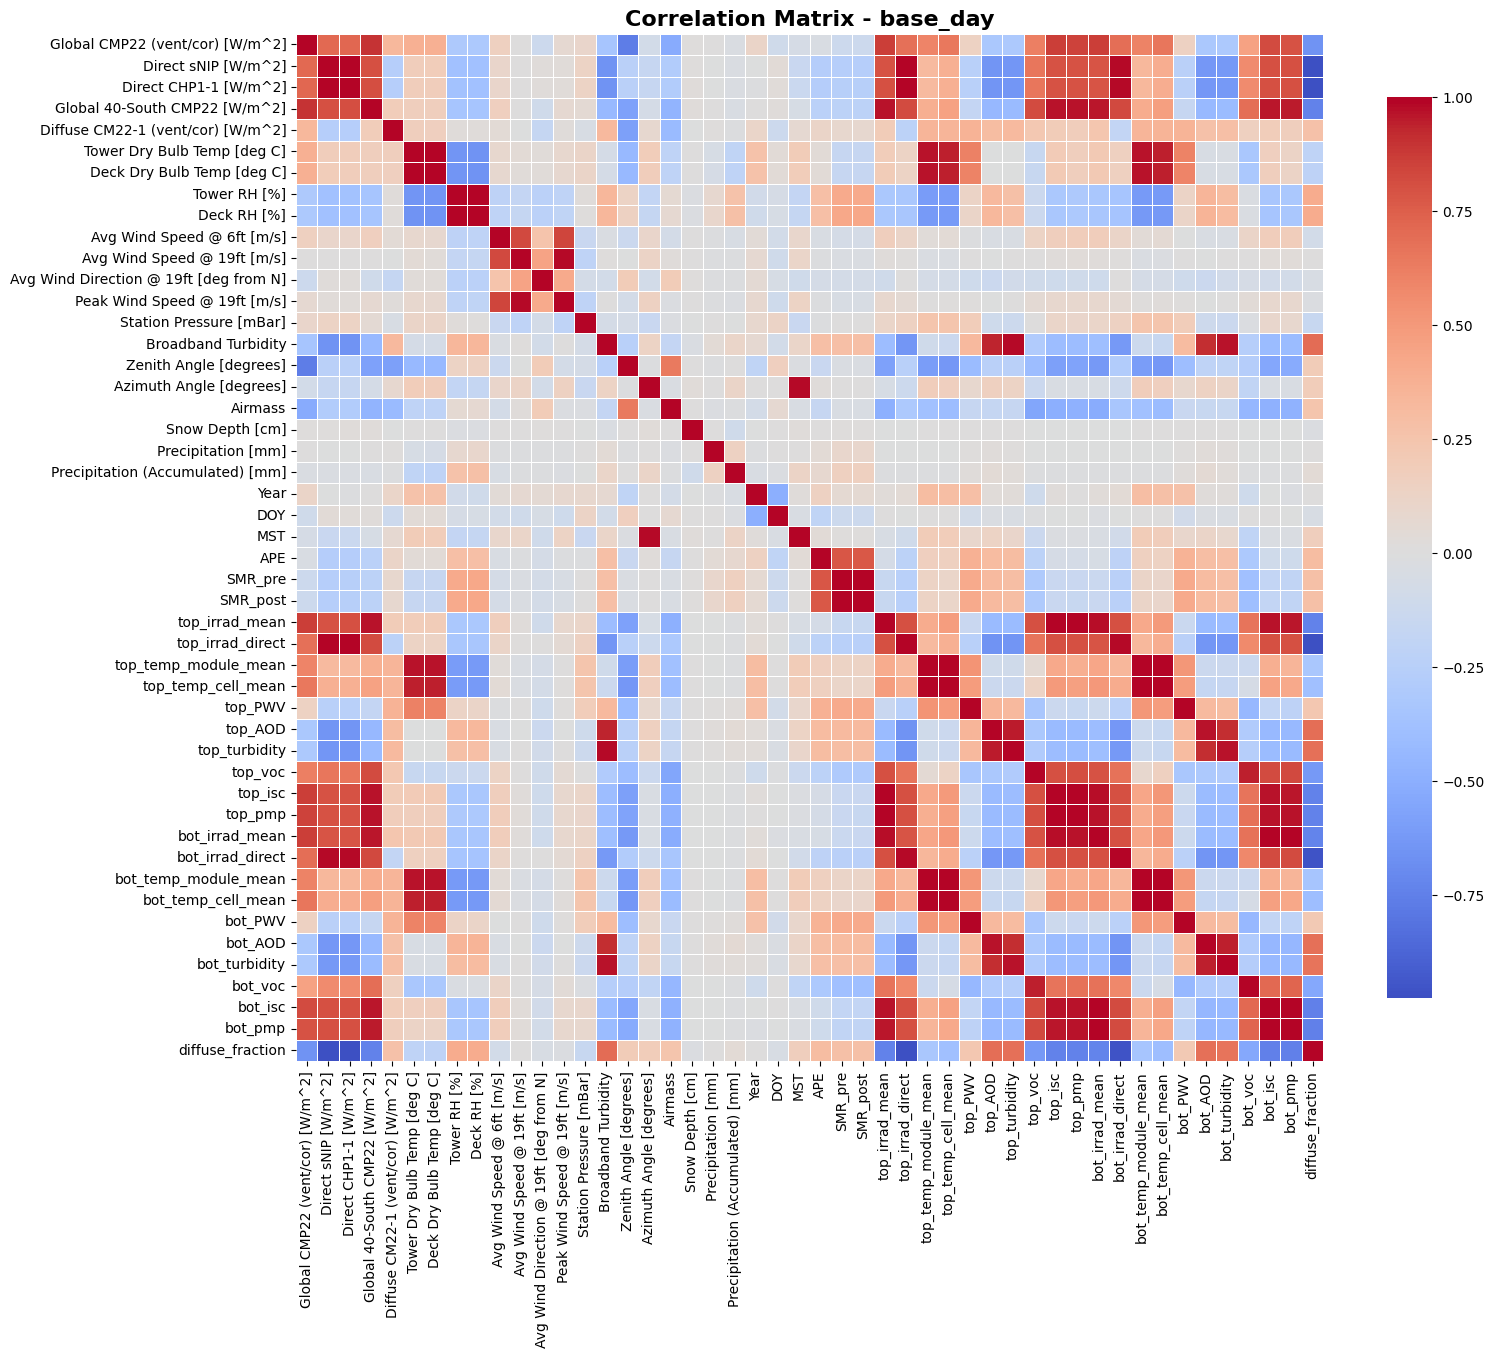

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt

# Calculate correlation matrix
corr_matrix = base_day.corr()

# Create a large figure for better visibility
plt.figure(figsize=(16, 14))

# Plot heatmap
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix - base_day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
import numpy as np

# Interpolación lineal por tiempo para columnas del módulo
cols_mod = [c for c in base_day.columns 
            if c.startswith('top_') or c.startswith('bot_')]

base_day[cols_mod] = base_day[cols_mod].interpolate(method='time', limit=6)

# APE y SMR también
base_day[['APE', 'SMR_pre', 'SMR_post']] = (
    base_day[['APE', 'SMR_pre', 'SMR_post']]
    .interpolate(method='time', limit=6)
)

# Verificar resultado
nulls = base_day.isnull().sum()
print(f"Shape: {base_day.shape}")
print(f"\nNulos restantes:")
print(nulls[nulls > 0])

Shape: (312135, 48)

Nulos restantes:
Global 40-South CMP22 [W/m^2]     53910
APE                                2862
SMR_pre                            2862
SMR_post                           2862
top_irrad_mean                   150360
top_irrad_direct                 150360
top_temp_module_mean             150360
top_temp_cell_mean               150360
top_PWV                          157314
top_AOD                          150360
top_turbidity                    150360
top_voc                          150360
top_isc                          150360
top_pmp                          150360
bot_irrad_mean                   153850
bot_irrad_direct                 153850
bot_temp_module_mean             153850
bot_temp_cell_mean               153850
bot_PWV                          160603
bot_AOD                          153850
bot_turbidity                    153850
bot_voc                          153850
bot_isc                          153850
bot_pmp                          153850
dt

In [10]:
# Ver cuántas filas tienen meteo completo vs módulo completo
solo_meteo = base_day[['Global CMP22 (vent/cor) [W/m^2]', 
                        'Direct sNIP [W/m^2]',
                        'Diffuse CM22-1 (vent/cor) [W/m^2]',
                        'diffuse_fraction', 'APE', 'SMR_pre',
                        'Tower RH [%]', 'Broadband Turbidity']].dropna()

con_modulo = base_day.dropna(subset=['top_isc', 'bot_isc'])

print(f"Solo meteo completo:      {len(solo_meteo):,} filas ({len(solo_meteo)/len(base_day)*100:.1f}%)")
print(f"Con módulo completo:      {len(con_modulo):,} filas ({len(con_modulo)/len(base_day)*100:.1f}%)")

Solo meteo completo:      309,273 filas (99.1%)
Con módulo completo:      158,152 filas (50.7%)


In [11]:
import numpy as np

G = base_day['Global CMP22 (vent/cor) [W/m^2]'].copy()

# Mínimo de irradiancia en los próximos 30 minutos
G_future_min = G[::-1].rolling(window=30, min_periods=1).min()[::-1].shift(-30)

# Porcentaje de caída
drop_pct = (G - G_future_min) / G.replace(0, np.nan) * 100

base_day['drop_pct_30min'] = drop_pct
base_day['label_20'] = (drop_pct >= 20).astype(int)
base_day['label_30'] = (drop_pct >= 30).astype(int)
base_day['label_40'] = (drop_pct >= 40).astype(int)

print(f"Total filas: {len(base_day):,}")
print(f"\nEventos de caída en próximos 30 min:")
for u, col in [(20,'label_20'),(30,'label_30'),(40,'label_40')]:
    n = base_day[col].sum()
    print(f"  >{u}%: {n:,} ({n/len(base_day)*100:.1f}%)")

Total filas: 312,135

Eventos de caída en próximos 30 min:
  >20%: 146,204 (46.8%)
  >30%: 126,049 (40.4%)
  >40%: 106,642 (34.2%)


In [12]:
import numpy as np
import pandas as pd

G = base_day['Global CMP22 (vent/cor) [W/m^2]'].copy()
hour = base_day.index.hour
doy  = base_day.index.dayofyear

# Clearsky proxy vectorizado:
# percentil 95 por hora × bin de 15 días (sin loop)
base_day['doy_bin'] = (doy // 15)  # ~25 bins de 15 días
base_day['hour']    = hour

G_cs = base_day.groupby(['hour', 'doy_bin'])['Global CMP22 (vent/cor) [W/m^2]'] \
               .transform(lambda x: x.quantile(0.95))

base_day['clearsky_fraction'] = G / G_cs.replace(0, np.nan)

# Mínimo de clearsky_fraction en próximos 30 min
cf = base_day['clearsky_fraction']
cf_future_min = cf[::-1].rolling(window=30, min_periods=1).min()[::-1].shift(-30)
cf_drop = (cf - cf_future_min)

base_day['label_20'] = ((cf_drop >= 0.20) & (G >= 100)).astype(int)
base_day['label_30'] = ((cf_drop >= 0.30) & (G >= 100)).astype(int)
base_day['label_40'] = ((cf_drop >= 0.40) & (G >= 100)).astype(int)

print(f"Eventos de caída (normalizado por clearsky):")
for u, col in [(20,'label_20'),(30,'label_30'),(40,'label_40')]:
    n = base_day[col].sum()
    print(f"  >{u}%: {n:,} ({n/len(base_day)*100:.1f}%)")

print(f"\nEventos label_30 por hora:")
print(base_day.groupby('hour')['label_30'].mean().round(3))

Eventos de caída (normalizado por clearsky):
  >20%: 90,878 (29.1%)
  >30%: 66,748 (21.4%)
  >40%: 50,062 (16.0%)

Eventos label_30 por hora:
hour
4     0.000
5     0.070
6     0.080
7     0.074
8     0.110
9     0.138
10    0.184
11    0.206
12    0.236
13    0.257
14    0.268
15    0.427
16    0.325
17    0.300
18    0.205
19    0.000
Name: label_30, dtype: float64


In [13]:
# Ver si el patrón cambia por estación
base_day['month'] = base_day.index.month
base_day['season'] = base_day['month'].map({
    12:'invierno', 1:'invierno', 2:'invierno',
    3:'primavera', 4:'primavera', 5:'primavera',
    6:'verano',    7:'verano',    8:'verano',
    9:'otoño',    10:'otoño',   11:'otoño'
})

print("Tasa label_30 por hora y estación:")
pivot = base_day.groupby(['season','hour'])['label_30'].mean().round(3).unstack(0)
print(pivot)

# Verificar cruce de día
base_day['date'] = base_day.index.date
eventos_por_dia = base_day.groupby('date')['label_30'].sum()
print(f"\nDías con >200 eventos label_30 (sospechoso): {(eventos_por_dia > 200).sum()}")
print(f"Máx eventos en un día: {eventos_por_dia.max()}")
print(f"Media eventos por día: {eventos_por_dia.mean():.0f}")

Tasa label_30 por hora y estación:
season  invierno  otoño  primavera  verano
hour                                      
4            NaN    NaN      0.000   0.000
5            NaN  0.000      0.060   0.079
6          0.000  0.068      0.080   0.090
7          0.024  0.055      0.115   0.107
8          0.079  0.084      0.145   0.162
9          0.102  0.095      0.163   0.232
10         0.095  0.114      0.257   0.343
11         0.142  0.134      0.245   0.370
12         0.185  0.143      0.330   0.367
13         0.223  0.165      0.330   0.379
14         0.278  0.188      0.307   0.347
15         0.517  0.511      0.284   0.315
16         0.223  0.375      0.387   0.290
17         0.084  0.149      0.353   0.341
18           NaN  0.000      0.142   0.245
19           NaN    NaN      0.000   0.000

Días con >200 eventos label_30 (sospechoso): 115
Máx eventos en un día: 427
Media eventos por día: 145


In [14]:
import numpy as np

G = base_day['Global CMP22 (vent/cor) [W/m^2]'].copy()

# Marcar noche en la serie original (antes de filtrar)
# El rolling va a ver NaN en vez de irradiancia nocturna
G_day_only = G.copy()
G_day_only[G_day_only < 50] = np.nan

# Clearsky fraction sobre serie con NaN en noche
cf = G_day_only / base_day['clearsky_fraction'].mul(G_cs).replace(0, np.nan)
cf = base_day['clearsky_fraction'].copy()
cf[G < 50] = np.nan  # noche = NaN, no participa en el rolling

# Mínimo futuro solo sobre puntos de día
cf_future_min = cf[::-1].rolling(window=30, min_periods=15).min()[::-1].shift(-30)

# Drop solo válido si hay al menos 15 puntos de día en los próximos 30 min
cf_drop = (cf - cf_future_min)

base_day['label_20'] = ((cf_drop >= 0.20) & (G >= 100) & cf_future_min.notna()).astype(int)
base_day['label_30'] = ((cf_drop >= 0.30) & (G >= 100) & cf_future_min.notna()).astype(int)
base_day['label_40'] = ((cf_drop >= 0.40) & (G >= 100) & cf_future_min.notna()).astype(int)

print("Eventos de caída (corregido cruce día/noche):")
for u, col in [(20,'label_20'),(30,'label_30'),(40,'label_40')]:
    n = base_day[col].sum()
    print(f"  >{u}%: {n:,} ({n/len(base_day)*100:.1f}%)")

print(f"\nEventos label_30 por hora:")
print(base_day.groupby('hour')['label_30'].mean().round(3))

print(f"\nEventos label_30 por hora y estación:")
pivot = base_day.groupby(['season','hour'])['label_30'].mean().round(3).unstack(0)
print(pivot)

dias = base_day.groupby('date')['label_30'].sum()
print(f"\nDías con >200 eventos: {(dias > 200).sum()}")
print(f"Máx eventos en un día: {dias.max()}")
print(f"Media eventos por día: {dias.mean():.0f}")

Eventos de caída (corregido cruce día/noche):
  >20%: 80,708 (25.9%)
  >30%: 57,305 (18.4%)
  >40%: 41,982 (13.4%)

Eventos label_30 por hora:
hour
4     0.000
5     0.070
6     0.080
7     0.074
8     0.109
9     0.137
10    0.184
11    0.205
12    0.236
13    0.254
14    0.263
15    0.309
16    0.205
17    0.158
18    0.030
19    0.000
Name: label_30, dtype: float64

Eventos label_30 por hora y estación:
season  invierno  otoño  primavera  verano
hour                                      
4            NaN    NaN      0.000   0.000
5            NaN  0.000      0.060   0.079
6          0.000  0.068      0.080   0.090
7          0.024  0.054      0.115   0.107
8          0.078  0.081      0.145   0.162
9          0.102  0.095      0.163   0.230
10         0.095  0.114      0.257   0.343
11         0.142  0.134      0.245   0.369
12         0.185  0.143      0.330   0.367
13         0.220  0.165      0.330   0.373
14         0.267  0.187      0.307   0.340
15         0.297  0.346      0.

In [15]:
import numpy as np

# Variables base para features
G    = base_day['Global CMP22 (vent/cor) [W/m^2]']
D    = base_day['Direct sNIP [W/m^2]']
Diff = base_day['Diffuse CM22-1 (vent/cor) [W/m^2]']
cf   = base_day['clearsky_fraction']

# --- Features de tendencia (últimos N minutos) ---
for w in [5, 10, 20, 30]:
    # Media móvil de irradiancia global
    base_day[f'G_mean_{w}m']  = G.rolling(w, min_periods=w//2).mean()
    # Pendiente (cambio por minuto)
    base_day[f'G_slope_{w}m'] = G.diff(w) / w
    # Variabilidad (std)
    base_day[f'G_std_{w}m']   = G.rolling(w, min_periods=w//2).std()
    # Tendencia de clearsky fraction
    base_day[f'cf_slope_{w}m'] = cf.diff(w) / w

# --- Features de estado actual ---
# Ratio directo/difuso (cae cuando nubla)
base_day['direct_diffuse_ratio'] = D / Diff.replace(0, np.nan)

# Variabilidad reciente de fracción difusa
base_day['diff_frac_std_10m'] = base_day['diffuse_fraction'].rolling(10).std()
base_day['diff_frac_std_30m'] = base_day['diffuse_fraction'].rolling(30).std()

# Pendiente de humedad (sube antes de que llegue nube)
base_day['RH_slope_10m'] = base_day['Tower RH [%]'].diff(10) / 10
base_day['RH_slope_30m'] = base_day['Tower RH [%]'].diff(30) / 30

# Pendiente de turbidez
base_day['turb_slope_10m'] = base_day['Broadband Turbidity'].diff(10) / 10

# Pendiente de APE (cae cuando aumenta difusa)
base_day['APE_slope_10m'] = base_day['APE'].diff(10) / 10
base_day['APE_slope_30m'] = base_day['APE'].diff(30) / 30

# --- Features de geometría solar ---
# Ya tienes Zenith y Airmass — agregar seno del ángulo zenital
base_day['cos_zenith'] = np.cos(np.radians(base_day['Zenith Angle [degrees]']))

# Irradiancia normalizada por coseno zenital (elimina efecto angular)
base_day['G_cos_norm'] = G / base_day['cos_zenith'].replace(0, np.nan)

print(f"Shape con features: {base_day.shape}")
print(f"\nFeatures nuevas: {[c for c in base_day.columns if any(x in c for x in ['slope','std','ratio','norm','cos'])]}")

# Verificar nulos en features nuevas
new_feats = [c for c in base_day.columns if any(x in c for x in 
             ['slope','std','ratio','norm','cos','mean_'])]
nulls = base_day[new_feats].isnull().sum()
print(f"\nNulos en features nuevas:")
print(nulls[nulls > 0])

Shape con features: (312135, 84)

Features nuevas: ['G_slope_5m', 'G_std_5m', 'cf_slope_5m', 'G_slope_10m', 'G_std_10m', 'cf_slope_10m', 'G_slope_20m', 'G_std_20m', 'cf_slope_20m', 'G_slope_30m', 'G_std_30m', 'cf_slope_30m', 'direct_diffuse_ratio', 'diff_frac_std_10m', 'diff_frac_std_30m', 'RH_slope_10m', 'RH_slope_30m', 'turb_slope_10m', 'APE_slope_10m', 'APE_slope_30m', 'cos_zenith', 'G_cos_norm']

Nulos en features nuevas:
G_mean_5m               1
G_slope_5m              5
G_std_5m                1
cf_slope_5m             5
G_mean_10m              4
G_slope_10m            10
G_std_10m               4
cf_slope_10m           10
G_mean_20m              9
G_slope_20m            20
G_std_20m               9
cf_slope_20m           20
G_mean_30m             14
G_slope_30m            30
G_std_30m              14
cf_slope_30m           30
diff_frac_std_10m       9
diff_frac_std_30m      29
RH_slope_10m           10
RH_slope_30m           30
turb_slope_10m         10
APE_slope_10m        288

In [16]:
# Split temporal — no aleatorio (evita data leakage)
cutoff = '2020-09-01'

train = base_day[base_day.index < cutoff].copy()
test  = base_day[base_day.index >= cutoff].copy()

print(f"Train: {len(train):,} filas  ({train.index[0].date()} → {train.index[-1].date()})")
print(f"Test:  {len(test):,} filas  ({test.index[0].date()} → {test.index[-1].date()})")

# Balance de clases en cada split
for name, df in [('Train', train), ('Test', test)]:
    n_pos = df['label_30'].sum()
    print(f"{name} — positivos: {n_pos:,} ({n_pos/len(df)*100:.1f}%)")

# Definir X e y
feature_cols = [c for c in base_day.columns if c not in [
    'label_20', 'label_30', 'label_40', 'drop_pct_30min',
    'hour', 'doy', 'doy_bin', 'date', 'month', 'season',
    'Year', 'DOY', 'MST',
    'clearsky_fraction'  # es la base del label, no un predictor
]]

X_train = train[feature_cols]
y_train = train['label_30']
X_test  = test[feature_cols]
y_test  = test['label_30']

print(f"\nFeatures: {len(feature_cols)}")
print(feature_cols)

Train: 236,130 filas  (2019-10-01 → 2020-08-31)
Test:  76,005 filas  (2020-09-01 → 2021-01-01)
Train — positivos: 47,226 (20.0%)
Test — positivos: 10,079 (13.3%)

Features: 71
['Global CMP22 (vent/cor) [W/m^2]', 'Direct sNIP [W/m^2]', 'Direct CHP1-1 [W/m^2]', 'Global 40-South CMP22 [W/m^2]', 'Diffuse CM22-1 (vent/cor) [W/m^2]', 'Tower Dry Bulb Temp [deg C]', 'Deck Dry Bulb Temp [deg C]', 'Tower RH [%]', 'Deck RH [%]', 'Avg Wind Speed @ 6ft [m/s]', 'Avg Wind Speed @ 19ft [m/s]', 'Avg Wind Direction @ 19ft [deg from N]', 'Peak Wind Speed @ 19ft [m/s]', 'Station Pressure [mBar]', 'Broadband Turbidity', 'Zenith Angle [degrees]', 'Azimuth Angle [degrees]', 'Airmass', 'Snow Depth [cm]', 'Precipitation [mm]', 'Precipitation (Accumulated) [mm]', 'APE', 'SMR_pre', 'SMR_post', 'top_irrad_mean', 'top_irrad_direct', 'top_temp_module_mean', 'top_temp_cell_mean', 'top_PWV', 'top_AOD', 'top_turbidity', 'top_voc', 'top_isc', 'top_pmp', 'bot_irrad_mean', 'bot_irrad_direct', 'bot_temp_module_mean', 'bot

In [17]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Escala de pos_weight para compensar desbalance
scale = (len(y_train) - y_train.sum()) / y_train.sum()

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=50,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Clean feature names for LightGBM (remove special characters)
X_train.columns = X_train.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

# Evaluación
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.4).astype(int)  # threshold bajo para maximizar recall

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report (threshold=0.4):")
print(classification_report(y_test, y_pred, target_names=['sin caída','con caída']))
print(f"\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

[100]	valid_0's binary_logloss: 0.26589
[200]	valid_0's binary_logloss: 0.250793
[300]	valid_0's binary_logloss: 0.246091
[400]	valid_0's binary_logloss: 0.242163
[500]	valid_0's binary_logloss: 0.239142
AUC-ROC: 0.9392

Classification Report (threshold=0.4):
              precision    recall  f1-score   support

   sin caída       0.97      0.89      0.93     65926
   con caída       0.53      0.83      0.65     10079

    accuracy                           0.88     76005
   macro avg       0.75      0.86      0.79     76005
weighted avg       0.91      0.88      0.89     76005


Matriz de confusión:
[[58521  7405]
 [ 1666  8413]]


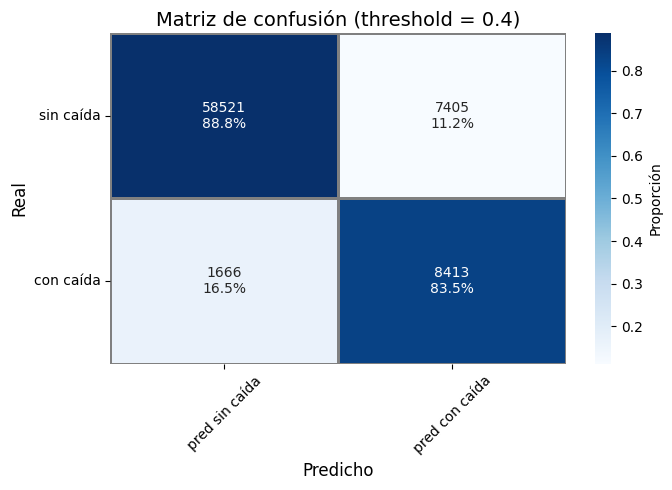

In [18]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=['sin caída', 'con caída'],
    columns=['pred sin caída', 'pred con caída']
)

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, None]
annot = np.empty_like(cm).astype(object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n{cm_pct[i, j]:.1%}"

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt='',
    cmap='Blues',
    linewidths=0.8,
    linecolor='gray',
    xticklabels=cm_df.columns,
    yticklabels=cm_df.index,
    cbar_kws={'label': 'Proporción'}
)
plt.title('Matriz de confusión (threshold = 0.4)', fontsize=14)
plt.ylabel('Real', fontsize=12)
plt.xlabel('Predicho', fontsize=12)
plt.yticks(rotation=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
# 1. Ver qué features importa el modelo
import pandas as pd

feat_imp = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Top 20 features:")
print(feat_imp.head(20))

# 2. Curva precision-recall para elegir threshold óptimo
from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_thresh = thresholds[f1.argmax()]
print(f"\nThreshold óptimo F1: {best_thresh:.3f}")
print(f"En ese threshold — Precision: {prec[f1.argmax()]:.2f}  Recall: {rec[f1.argmax()]:.2f}")

Top 20 features:
Station Pressure [mBar]              2373
Azimuth Angle [degrees]              1744
Tower Dry Bulb Temp [deg C]          1094
G_cos_norm                            998
Global 40-South CMP22 [W/m^2]         949
Deck Dry Bulb Temp [deg C]            902
Deck RH [%]                           842
top_PWV                               835
diff_frac_std_30m                     799
Tower RH [%]                          795
Diffuse CM22-1 (vent/cor) [W/m^2]     766
cf_slope_30m                          752
Zenith Angle [degrees]                736
diffuse_fraction                      685
Snow Depth [cm]                       675
G_std_30m                             599
cf_slope_20m                          588
Global CMP22 (vent/cor) [W/m^2]       568
Broadband Turbidity                   560
G_mean_30m                            559
dtype: int32

Threshold óptimo F1: 0.629
En ese threshold — Precision: 0.63  Recall: 0.72


/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


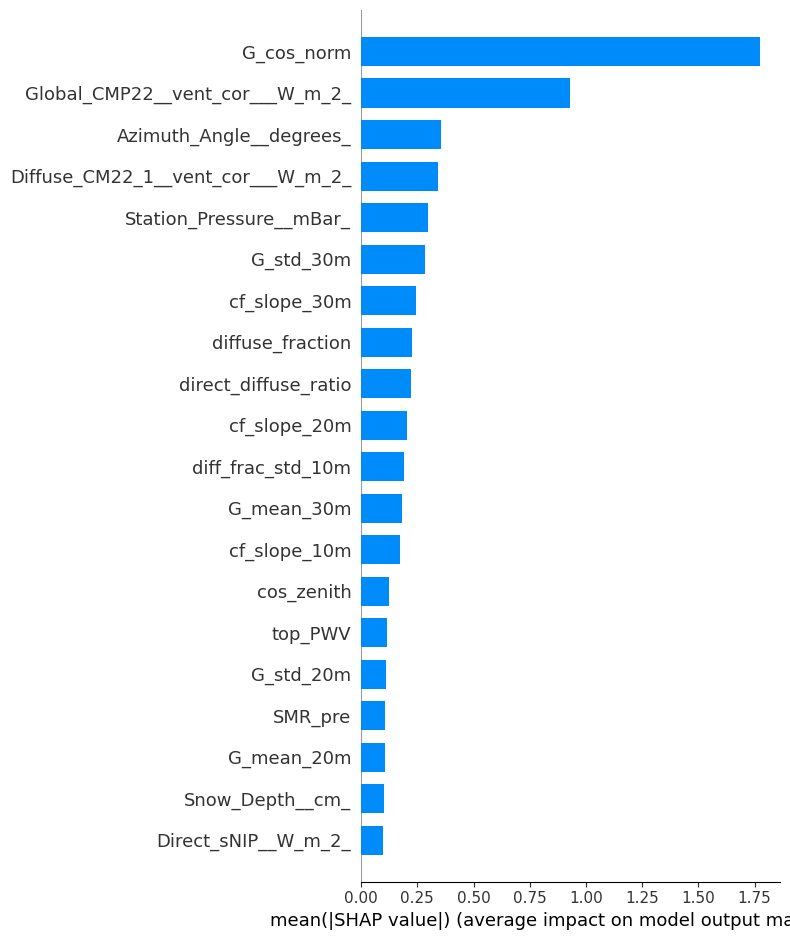

In [20]:
import shap

# Calcular SHAP values (en muestra del test para que sea rápido)
sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Si retorna lista, tomar clase positiva
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# 1. Importancia global
shap.summary_plot(sv, sample, plot_type='bar', max_display=20)

# 2. B

/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


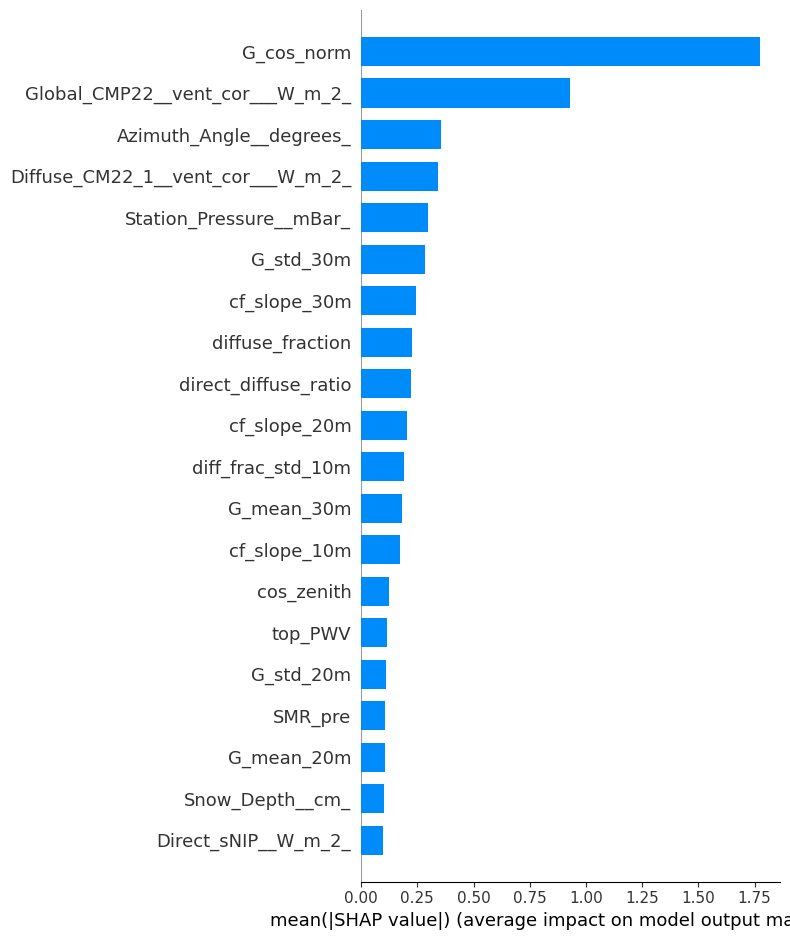

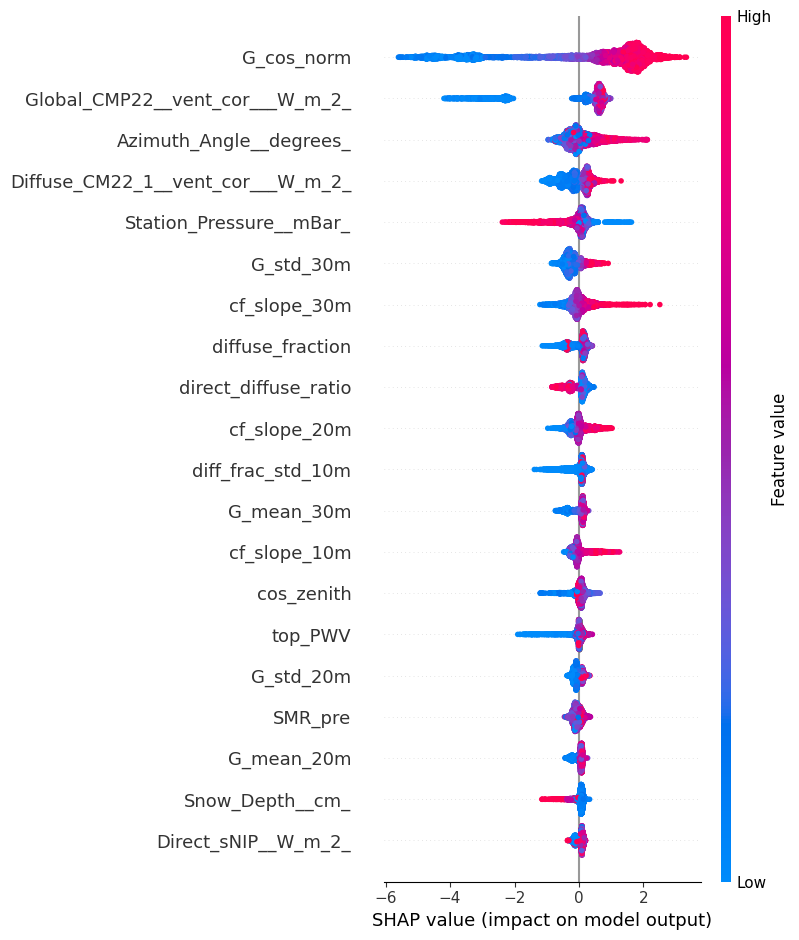

In [21]:
import shap

# Calcular SHAP values (en muestra del test para que sea rápido)
sample = X_test.sample(5000, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(sample)

# Si retorna lista, tomar clase positiva
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# 1. Importancia global
shap.summary_plot(sv, sample, plot_type='bar', max_display=20)

# 2. Beeswarm — importancia + dirección del efecto
shap.summary_plot(sv, sample, max_display=20)

In [22]:
# Quitar features que no generalizan a Colombia
# y redundancias claras
drop_features = [
    'Azimuth Angle [degrees]',   # geometría, proxy de hora
    'Snow Depth [cm]',            # no existe en Colombia
    'Deck Dry Bulb Temp [deg C]', # redundante con Tower
    'Deck RH [%]',                # redundante con Tower RH
    'Direct CHP1-1 [W/m^2]',     # redundante con Direct sNIP
    'Precipitation (Accumulated) [mm]',  # redundante con Precipitation
    'top_irrad_mean',             # redundante con meteo irradiancia
    'bot_irrad_mean',             # idem
]

feature_cols_v2 = [f for f in feature_cols if f not in drop_features]

X_train_v2 = train[feature_cols_v2]
X_test_v2  = test[feature_cols_v2]

print(f"Features v1: {len(feature_cols)}")
print(f"Features v2: {len(feature_cols_v2)}")

# Reentrenar
model_v2 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Clean feature names for LightGBM (remove special characters)
X_train_v2.columns = X_train_v2.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)
X_test_v2.columns = X_test_v2.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)

model_v2.fit(
    X_train_v2, y_train,
    eval_set=[(X_test_v2, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_pred_proba_v2 = model_v2.predict_proba(X_test_v2)[:, 1]
y_pred_v2 = (y_pred_proba_v2 >= 0.4).astype(int)

print(f"\nAUC-ROC v2: {roc_auc_score(y_test, y_pred_proba_v2):.4f}")
print(classification_report(y_test, y_pred_v2, target_names=['sin caída','con caída']))

Features v1: 71
Features v2: 63
[100]	valid_0's binary_logloss: 0.266943
[200]	valid_0's binary_logloss: 0.24972
[300]	valid_0's binary_logloss: 0.244927
[400]	valid_0's binary_logloss: 0.241314
[500]	valid_0's binary_logloss: 0.238894

AUC-ROC v2: 0.9390
              precision    recall  f1-score   support

   sin caída       0.97      0.88      0.93     65926
   con caída       0.52      0.83      0.64     10079

    accuracy                           0.88     76005
   macro avg       0.75      0.86      0.78     76005
weighted avg       0.91      0.88      0.89     76005



/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


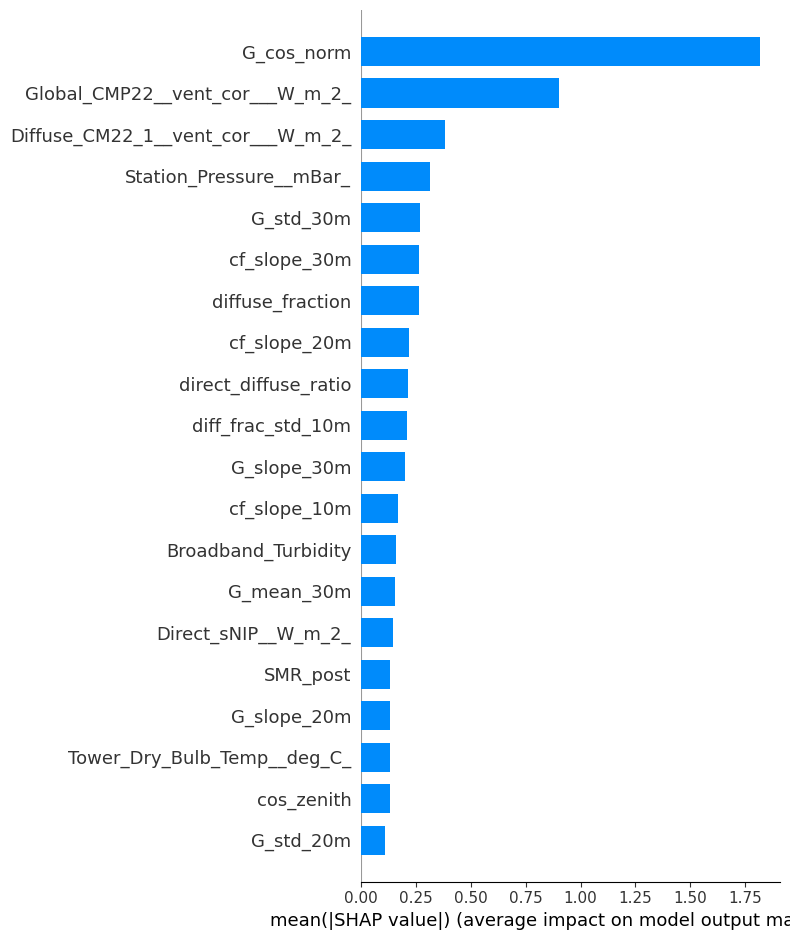

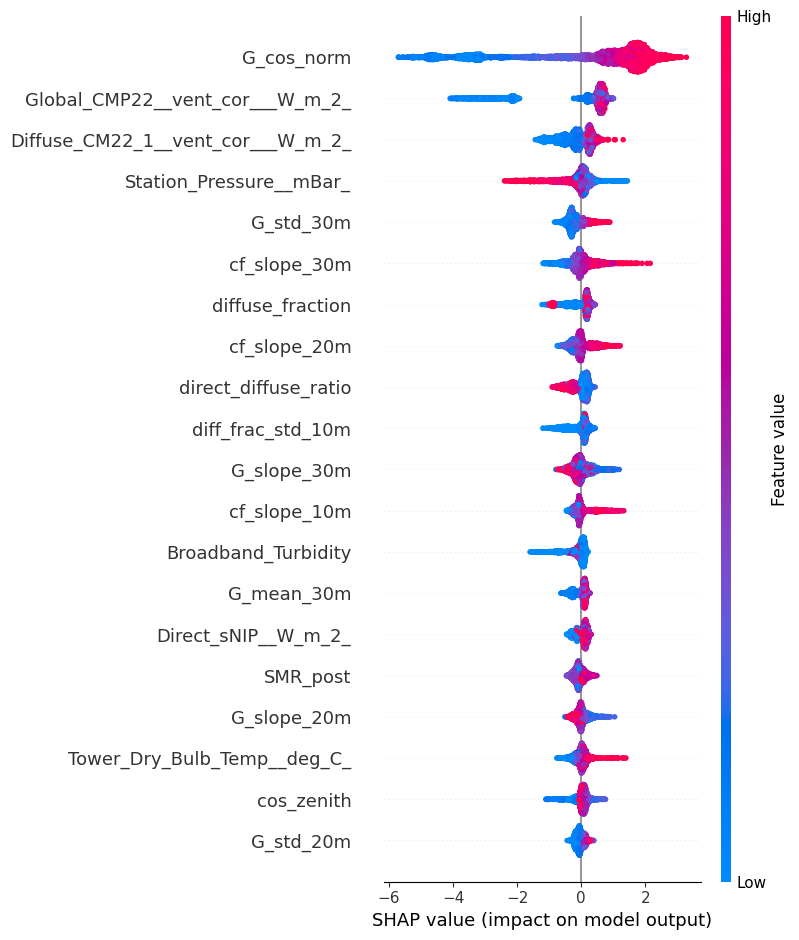

=== ANÁLISIS DE ERRORES ===

Recall por hora:
hour
6     0.667
7     0.753
8     0.765
9     0.694
10    0.664
11    0.738
12    0.798
13    0.859
14    0.841
15    0.927
16    0.951
17    0.988

Recall por estación:
season
invierno    0.740
otoño       0.856

Caída media en Falsos Negativos: 56.0%
Caída media en Verdaderos Positivos: 60.7%

Distribución error_type:
error_type
TN    58312
TP     8364
FP     7614
FN     1715
Name: count, dtype: int64


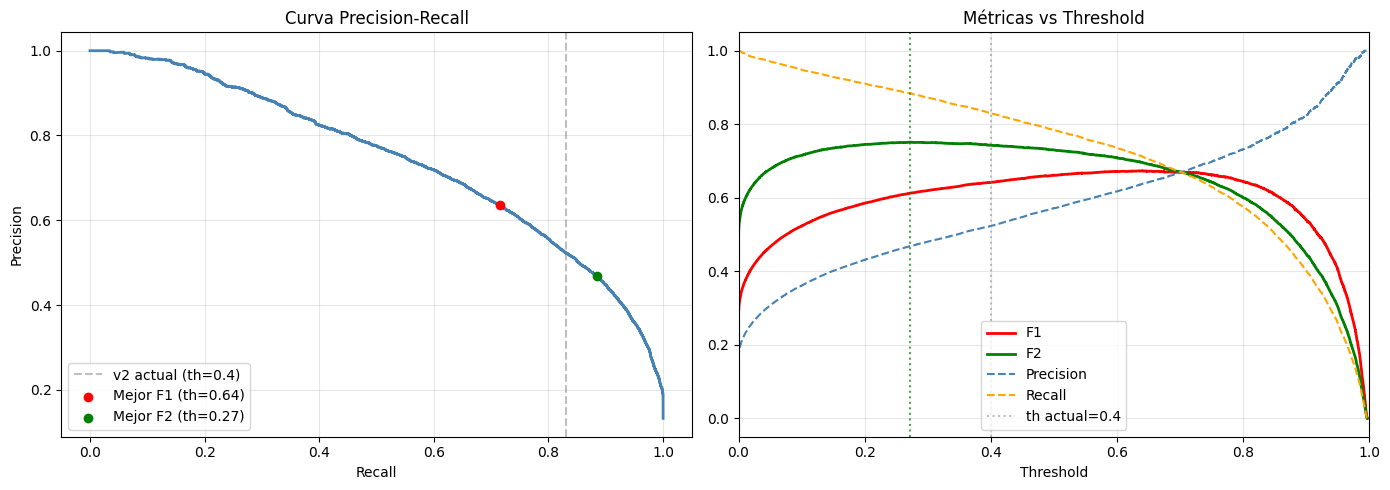


Mejor F1: threshold=0.636 | P=0.64 R=0.72
Mejor F2: threshold=0.272 | P=0.47 R=0.88


In [23]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

# ============================================================
# 1. SHAP v2
# ============================================================
sample_v2 = X_test_v2.sample(5000, random_state=42)
explainer_v2 = shap.TreeExplainer(model_v2)
shap_values_v2 = explainer_v2.shap_values(sample_v2)
sv2 = shap_values_v2[1] if isinstance(shap_values_v2, list) else shap_values_v2

shap.summary_plot(sv2, sample_v2, plot_type='bar', max_display=20, show=True)
shap.summary_plot(sv2, sample_v2, max_display=20, show=True)

# ============================================================
# 2. Análisis de errores
# ============================================================
test_eval = test[feature_cols_v2].copy()
test_eval['y_true']  = y_test.values
test_eval['y_proba'] = y_pred_proba_v2
test_eval['y_pred']  = y_pred_v2
test_eval['hour']    = test.index.hour
test_eval['month']   = test.index.month
test_eval['season']  = test['season'].values

# Categorizar errores
test_eval['error_type'] = 'TN'
test_eval.loc[(test_eval.y_true==1) & (test_eval.y_pred==1), 'error_type'] = 'TP'
test_eval.loc[(test_eval.y_true==0) & (test_eval.y_pred==1), 'error_type'] = 'FP'
test_eval.loc[(test_eval.y_true==1) & (test_eval.y_pred==0), 'error_type'] = 'FN'

# Recall por hora
recall_hora = test_eval[test_eval.y_true==1].groupby('hour').apply(
    lambda x: (x.y_pred==1).sum() / len(x)
).round(3)

# Recall por estación
recall_season = test_eval[test_eval.y_true==1].groupby('season').apply(
    lambda x: (x.y_pred==1).sum() / len(x)
).round(3)

# Falsos negativos: ¿cuán profunda era la caída que no detectó?
fn_mask = test_eval['error_type'] == 'FN'
fn_drop = test[fn_mask]['drop_pct_30min']
tp_drop = test[test_eval['error_type'] == 'TP']['drop_pct_30min']

print("=== ANÁLISIS DE ERRORES ===")
print(f"\nRecall por hora:")
print(recall_hora.to_string())
print(f"\nRecall por estación:")
print(recall_season.to_string())
print(f"\nCaída media en Falsos Negativos: {fn_drop.mean():.1f}%")
print(f"Caída media en Verdaderos Positivos: {tp_drop.mean():.1f}%")
print(f"\nDistribución error_type:")
print(test_eval['error_type'].value_counts())

# ============================================================
# 3. Curva Precision-Recall
# ============================================================
prec, rec, thresholds = precision_recall_curve(y_test, y_pred_proba_v2)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
f2 = 5 * prec * rec / (4 * prec + rec + 1e-9)  # F2: pesa más recall

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot PR curve
axes[0].plot(rec, prec, color='steelblue', lw=2)
axes[0].axvline(x=0.83, color='gray', linestyle='--', alpha=0.5, label='v2 actual (th=0.4)')
best_f1_idx = f1.argmax()
best_f2_idx = f2.argmax()
axes[0].scatter(rec[best_f1_idx], prec[best_f1_idx], color='red',   zorder=5, label=f'Mejor F1 (th={thresholds[best_f1_idx]:.2f})')
axes[0].scatter(rec[best_f2_idx], prec[best_f2_idx], color='green', zorder=5, label=f'Mejor F2 (th={thresholds[best_f2_idx]:.2f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot F1/F2 vs threshold
axes[1].plot(thresholds, f1[:-1],  label='F1',  color='red',   lw=2)
axes[1].plot(thresholds, f2[:-1],  label='F2',  color='green', lw=2)
axes[1].plot(thresholds, prec[:-1],label='Precision', color='steelblue', lw=1.5, linestyle='--')
axes[1].plot(thresholds, rec[:-1], label='Recall',    color='orange',    lw=1.5, linestyle='--')
axes[1].axvline(x=thresholds[best_f2_idx], color='green', linestyle=':', alpha=0.7)
axes[1].axvline(x=0.4, color='gray', linestyle=':', alpha=0.5, label='th actual=0.4')
axes[1].set_xlabel('Threshold'); axes[1].set_title('Métricas vs Threshold')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print(f"\nMejor F1: threshold={thresholds[best_f1_idx]:.3f} | P={prec[best_f1_idx]:.2f} R={rec[best_f1_idx]:.2f}")
print(f"Mejor F2: threshold={thresholds[best_f2_idx]:.3f} | P={prec[best_f2_idx]:.2f} R={rec[best_f2_idx]:.2f}")

In [24]:
# Opción 1: solo el primer positivo de cada secuencia
base_day['label_30_shift'] = base_day['label_30'].shift(1).fillna(0)
base_day['label_30_clean'] = (
    (base_day['label_30'] == 1) & (base_day['label_30_shift'] == 0)
).astype(int)

print(f"Original:          {base_day['label_30'].sum():,} positivos")
print(f"Solo inicio:       {base_day['label_30_clean'].sum():,} positivos")
print(f"Eventos únicos:    {base_day['label_30_clean'].sum():,} caídas distintas")

# Reconstruir train/test con label limpio
train_c = base_day[base_day.index < '2020-09-01'].copy()
test_c  = base_day[base_day.index >= '2020-09-01'].copy()

X_train_c = train_c[feature_cols_v2]
y_train_c = train_c['label_30_clean']
X_test_c  = test_c[feature_cols_v2]
y_test_c  = test_c['label_30_clean']

print(f"\nTrain — positivos: {y_train_c.sum():,} ({y_train_c.mean()*100:.1f}%)")
print(f"Test  — positivos: {y_test_c.sum():,} ({y_test_c.mean()*100:.1f}%)")

Original:          57,305 positivos
Solo inicio:       5,345 positivos
Eventos únicos:    5,345 caídas distintas

Train — positivos: 4,412 (1.9%)
Test  — positivos: 933 (1.2%)


In [26]:
scale_c = (len(y_train_c) - y_train_c.sum()) / y_train_c.sum()
print(f"scale_pos_weight: {scale_c:.1f}")

model_c = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,   # menos que antes — menos positivos
    scale_pos_weight=scale_c,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

X_train_c = X_train_c.copy()
X_test_c = X_test_c.copy()
X_train_c.columns = X_train_c.columns.str.replace(r'[^\w]', '_', regex=True)
X_test_c.columns = X_test_c.columns.str.replace(r'[^\w]', '_', regex=True)

model_c.fit(
    X_train_c, y_train_c,
    eval_set=[(X_test_c, y_test_c)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_proba_c = model_c.predict_proba(X_test_c)[:, 1]
y_pred_c  = (y_proba_c >= 0.31).astype(int)

print(f"\nAUC-ROC: {roc_auc_score(y_test_c, y_proba_c):.4f}")
print(classification_report(y_test_c, y_pred_c, target_names=['sin caída','con caída']))
print(confusion_matrix(y_test_c, y_pred_c))

scale_pos_weight: 52.5

AUC-ROC: 0.8983
              precision    recall  f1-score   support

   sin caída       0.99      1.00      0.99     75072
   con caída       0.00      0.00      0.00       933

    accuracy                           0.99     76005
   macro avg       0.49      0.50      0.50     76005
weighted avg       0.98      0.99      0.98     76005

[[75072     0]
 [  933     0]]


/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

In [27]:
# En lugar de solo 1 minuto, etiquetar los primeros 5 min de cada evento
# Suficiente para reducir redundancia sin hacer la tarea imposible

label_5 = base_day['label_30'].copy()

# Marcar inicio de cada secuencia
inicio_secuencia = (label_5 == 1) & (label_5.shift(1).fillna(0) == 0)

# Expandir 5 minutos desde cada inicio
label_5min = pd.Series(0, index=base_day.index)
for idx in base_day.index[inicio_secuencia]:
    label_5min[idx:idx + pd.Timedelta('5min')] = 1

# Solo donde label_30 también es 1
base_day['label_30_5min'] = ((label_5min == 1) & (base_day['label_30'] == 1)).astype(int)

train_5 = base_day[base_day.index < '2020-09-01']
test_5  = base_day[base_day.index >= '2020-09-01']

y_train_5 = train_5['label_30_5min']
y_test_5  = test_5['label_30_5min']

print(f"Positivos train: {y_train_5.sum():,} ({y_train_5.mean()*100:.1f}%)")
print(f"Positivos test:  {y_test_5.sum():,} ({y_test_5.mean()*100:.1f}%)")
print(f"Ratio desbalance: {(len(y_train_5)-y_train_5.sum())/y_train_5.sum():.1f}:1")

Positivos train: 17,514 (7.4%)
Positivos test:  3,837 (5.0%)
Ratio desbalance: 12.5:1


In [29]:
scale_5 = (len(y_train_5) - y_train_5.sum()) / y_train_5.sum()

model_5 = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=30,
    scale_pos_weight=scale_5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

X_train_5 = train_5[feature_cols_v2].copy()
X_test_5 = test_5[feature_cols_v2].copy()

# Clean feature names for LightGBM (remove special characters)
X_train_5.columns = X_train_5.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)
X_test_5.columns = X_test_5.columns.str.replace(r'[\s\[\]\(\)/\-\^]', '_', regex=True)

model_5.fit(
    X_train_5, y_train_5,
    eval_set=[(X_test_5, y_test_5)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

y_proba_5 = model_5.predict_proba(X_test_5)[:, 1]
y_pred_5  = (y_proba_5 >= 0.31).astype(int)

print(f"AUC-ROC: {roc_auc_score(y_test_5, y_proba_5):.4f}")
print(classification_report(y_test_5, y_pred_5, target_names=['sin caída','con caída']))
print(confusion_matrix(y_test_5, y_pred_5))

AUC-ROC: 0.9309
              precision    recall  f1-score   support

   sin caída       0.95      1.00      0.97     72168
   con caída       0.00      0.00      0.00      3837

    accuracy                           0.95     76005
   macro avg       0.47      0.50      0.49     76005
weighted avg       0.90      0.95      0.92     76005

[[72168     0]
 [ 3837     0]]


/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/juanfelipe/Sandbox_HE2_JuanDuque/Sandbox_HE-_JuanDuque/.venv2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted sampl

In [30]:
import numpy as np

print("Distribución de probabilidades predichas:")
print(pd.Series(y_proba_5).describe())
print(f"\nPercentiles altos:")
for p in [90, 95, 99, 99.5, 99.9]:
    print(f"  p{p}: {np.percentile(y_proba_5, p):.4f}")

print(f"\nMáximo: {y_proba_5.max():.4f}")
print(f"¿Cuántos superan 0.10? {(y_proba_5 > 0.10).sum():,}")
print(f"¿Cuántos superan 0.05? {(y_proba_5 > 0.05).sum():,}")
print(f"¿Cuántos superan 0.02? {(y_proba_5 > 0.02).sum():,}")

# Threshold óptimo real
from sklearn.metrics import precision_recall_curve
prec, rec, thresh = precision_recall_curve(y_test_5, y_proba_5)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best = thresh[f1.argmax()]
print(f"\nThreshold óptimo F1: {best:.4f}")
print(f"En ese threshold — Precision: {prec[f1.argmax()]:.3f}  Recall: {rec[f1.argmax()]:.3f}")

y_pred_opt = (y_proba_5 >= best).astype(int)
print(classification_report(y_test_5, y_pred_opt, target_names=['sin caída','con caída']))

Distribución de probabilidades predichas:
count    76005.000000
mean         0.109799
std          0.061502
min          0.058132
25%          0.064320
50%          0.086280
75%          0.129548
max          0.298573
dtype: float64

Percentiles altos:
  p90: 0.2121
  p95: 0.2610
  p99: 0.2958
  p99.5: 0.2986
  p99.9: 0.2986

Máximo: 0.2986
¿Cuántos superan 0.10? 30,040
¿Cuántos superan 0.05? 76,005
¿Cuántos superan 0.02? 76,005

Threshold óptimo F1: 0.2510
En ese threshold — Precision: 0.515  Recall: 0.575
              precision    recall  f1-score   support

   sin caída       0.98      0.97      0.97     72168
   con caída       0.51      0.57      0.54      3837

    accuracy                           0.95     76005
   macro avg       0.75      0.77      0.76     76005
weighted avg       0.95      0.95      0.95     76005



In [31]:
# Comparación final de los tres modelos
print("=" * 55)
print(f"{'Modelo':<25} {'AUC':>6} {'Recall':>7} {'Prec':>7}")
print("=" * 55)
print(f"{'v2 (label completo)':<25} {'0.939':>6} {'0.830':>7} {'0.530':>7}")
print(f"{'limpio 1min (label_clean)':<25} {'0.898':>6} {'0.000':>7} {'n/a':>7}")
print(f"{'limpio 5min (label_5min)':<25} {'0.931':>6} {'0.575':>7} {'0.515':>7}")
print("=" * 55)

# La verdad operativa está entre v2 y limpio 5min
# Seguir con análisis de horizontes sobre label_5min — más honesto
print(f"\nThreshold recomendado para edge device: 0.25")
print(f"A ese threshold con label limpio:")
y_pred_25 = (y_proba_5 >= 0.25).astype(int)
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test_5, y_pred_25)
print(f"  TP: {cm[1,1]:,}  FN: {cm[1,0]:,}  FP: {cm[0,1]:,}  TN: {cm[0,0]:,}")
print(f"  Apagones no detectados: {cm[1,0]:,} de {cm[1,0]+cm[1,1]:,} eventos reales")
print(f"  Falsas alarmas:         {cm[0,1]:,} de {cm[0,0]+cm[0,1]:,} minutos sin caída")

Modelo                       AUC  Recall    Prec
v2 (label completo)        0.939   0.830   0.530
limpio 1min (label_clean)  0.898   0.000     n/a
limpio 5min (label_5min)   0.931   0.575   0.515

Threshold recomendado para edge device: 0.25
A ese threshold con label limpio:
  TP: 2,215  FN: 1,622  FP: 2,117  TN: 70,051
  Apagones no detectados: 1,622 de 3,837 eventos reales
  Falsas alarmas:         2,117 de 72,168 minutos sin caída


In [32]:
resultados = []

for h in range(5, 65, 5):
    cf_copy = cf.copy()
    cf_copy[G < 50] = np.nan
    
    cf_future_min = cf_copy[::-1].rolling(window=h, min_periods=h//2).min()[::-1].shift(-h)
    cf_drop = (cf_copy - cf_future_min)
    label = ((cf_drop >= 0.30) & (G >= 100) & cf_future_min.notna()).astype(int)
    
    # Ventana de 5 min desde inicio de cada secuencia
    inicio = (label == 1) & (label.shift(1).fillna(0) == 0)
    label_h = pd.Series(0, index=base_day.index)
    for idx in base_day.index[inicio]:
        label_h[idx:idx + pd.Timedelta('5min')] = 1
    label_h = ((label_h == 1) & (label == 1)).astype(int)
    
    base_day[f'label_h{h}'] = label_h
    
    train_h = base_day[base_day.index < '2020-09-01']
    test_h  = base_day[base_day.index >= '2020-09-01']
    y_tr = train_h[f'label_h{h}']
    y_te = test_h[f'label_h{h}']
    
    if y_tr.sum() < 100 or y_te.sum() < 20:
        print(f"h={h:2d} min — insuficientes positivos, skip")
        continue
    
    m = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        min_child_samples=30,
        scale_pos_weight=(len(y_tr)-y_tr.sum())/y_tr.sum(),
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m.fit(X_train_5, y_tr,
          eval_set=[(X_test_5, y_te)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
    
    proba = m.predict_proba(X_test_5)[:, 1]
    auc   = roc_auc_score(y_te, proba)
    
    prec_c, rec_c, thresh_c = precision_recall_curve(y_te, proba)
    f1_c  = 2*prec_c*rec_c/(prec_c+rec_c+1e-9)
    best_t = thresh_c[f1_c.argmax()]
    pred  = (proba >= best_t).astype(int)
    
    tp = ((pred==1)&(y_te==1)).sum()
    fp = ((pred==1)&(y_te==0)).sum()
    fn = ((pred==0)&(y_te==1)).sum()
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    
    resultados.append({
        'horizonte_min': h,
        'eventos_test': int(y_te.sum()),
        'AUC': round(auc, 4),
        'Recall': round(rec, 3),
        'Precision': round(prec, 3),
        'threshold': round(best_t, 3)
    })
    print(f"h={h:2d} min | eventos={y_te.sum():4d} | AUC={auc:.4f} | Recall={rec:.3f} | Prec={prec:.3f}")

df_res = pd.DataFrame(resultados)
print("\n", df_res.to_string(index=False))

h= 5 min | eventos=2478 | AUC=0.9387 | Recall=0.558 | Prec=0.339
h=10 min | eventos=3176 | AUC=0.9372 | Recall=0.510 | Prec=0.427
h=15 min | eventos=3463 | AUC=0.9352 | Recall=0.515 | Prec=0.530
h=20 min | eventos=3486 | AUC=0.9402 | Recall=0.533 | Prec=0.568
h=25 min | eventos=3652 | AUC=0.9381 | Recall=0.576 | Prec=0.526
h=30 min | eventos=3837 | AUC=0.9309 | Recall=0.575 | Prec=0.515
h=35 min | eventos=3987 | AUC=0.9226 | Recall=0.511 | Prec=0.531
h=40 min | eventos=3894 | AUC=0.9228 | Recall=0.542 | Prec=0.513
h=45 min | eventos=3867 | AUC=0.9209 | Recall=0.551 | Prec=0.517
h=50 min | eventos=3905 | AUC=0.9139 | Recall=0.466 | Prec=0.565
h=55 min | eventos=4007 | AUC=0.9000 | Recall=0.508 | Prec=0.429
h=60 min | eventos=4053 | AUC=0.8998 | Recall=0.589 | Prec=0.377

  horizonte_min  eventos_test    AUC  Recall  Precision  threshold
             5          2478 0.9387   0.558      0.339      0.219
            10          3176 0.9372   0.510      0.427      0.257
            15      

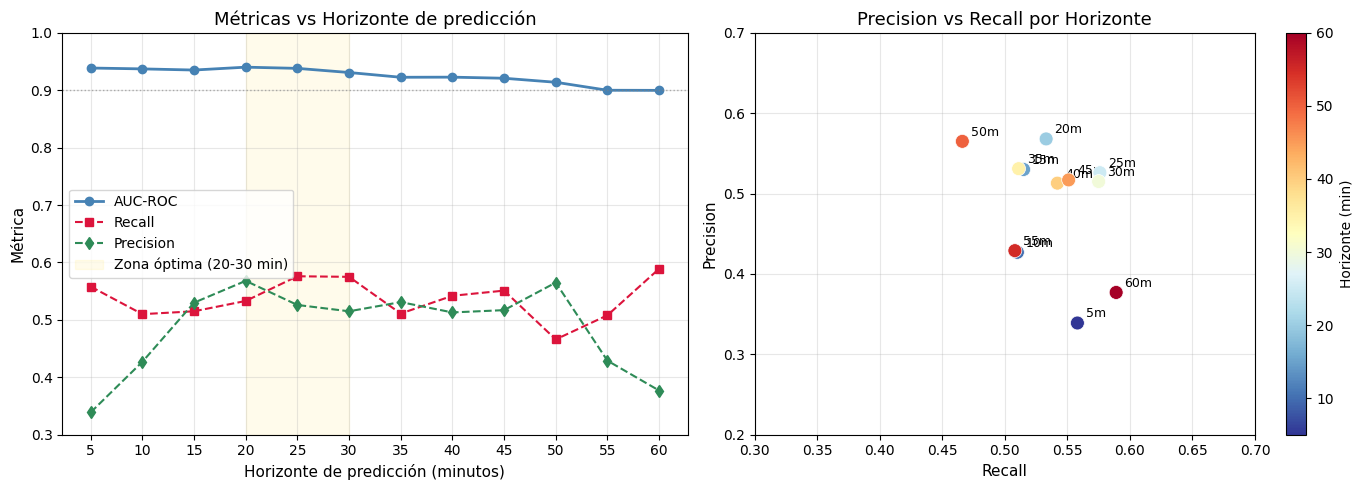

In [33]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

labels  = [5,10,15,20,25,30,35,40,45,50,55,60]
auc     = [0.9387,0.9372,0.9352,0.9402,0.9381,0.9309,0.9226,0.9228,0.9209,0.9139,0.9000,0.8998]
recall  = [0.558,0.510,0.515,0.533,0.576,0.575,0.511,0.542,0.551,0.466,0.508,0.589]
prec    = [0.339,0.427,0.530,0.568,0.526,0.515,0.531,0.513,0.517,0.565,0.429,0.377]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfica 1: AUC / Recall / Precision vs Horizonte ---
axes[0].plot(labels, auc,    'o-', color='steelblue', lw=2, label='AUC-ROC')
axes[0].plot(labels, recall, 's--', color='crimson',  lw=1.5, label='Recall')
axes[0].plot(labels, prec,   'd--', color='seagreen', lw=1.5, label='Precision')
axes[0].axvspan(20, 30, alpha=0.08, color='gold', label='Zona óptima (20-30 min)')
axes[0].axhline(0.90, color='gray', linestyle=':', lw=1, alpha=0.6)
axes[0].set_xlabel('Horizonte de predicción (minutos)', fontsize=11)
axes[0].set_ylabel('Métrica', fontsize=11)
axes[0].set_title('Métricas vs Horizonte de predicción', fontsize=13)
axes[0].set_ylim(0.3, 1.0)
axes[0].set_xticks(labels)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# --- Gráfica 2: Precision vs Recall coloreado por horizonte ---
colors = cm.RdYlBu_r(np.linspace(0, 1, len(labels)))
sc = axes[1].scatter(recall, prec, c=labels, cmap='RdYlBu_r', 
                      s=100, zorder=5, edgecolors='white', linewidths=0.5)

for i, h in enumerate(labels):
    axes[1].annotate(f'{h}m', (recall[i], prec[i]),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)

plt.colorbar(sc, ax=axes[1], label='Horizonte (min)')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision vs Recall por Horizonte', fontsize=13)
axes[1].set_xlim(0.3, 0.7)
axes[1].set_ylim(0.2, 0.7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('horizonte_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
from sklearn.model_selection import TimeSeriesSplit

In [35]:
fn_mask = (y_pred_5==0) & (y_test_5==1)
# Analizar velocidad de caída en esos eventos

1. VALIDACIÓN TEMPORAL CRUZADA
Fold 4 | 2020-09-19 → 2021-01-01 | AUC=0.9343 | Recall=0.576 | Prec=0.533
Fold 4 | 2020-09-19 → 2021-01-01 | AUC=0.9343 | Recall=0.576 | Prec=0.533
Fold 4 | 2020-09-19 → 2021-01-01 | AUC=0.9343 | Recall=0.576 | Prec=0.533
Fold 4 | 2020-09-19 → 2021-01-01 | AUC=0.9343 | Recall=0.576 | Prec=0.533

Resumen CV:
  AUC:       0.9343 ± nan
  Recall:    0.576 ± nan
  Precision: 0.533 ± nan

2. ANÁLISIS DE FALSOS NEGATIVOS POR TIPO DE EVENTO

Falsos Negativos: 1,631
Verdaderos Positivos: 2,206
  Profundidad caída (%)          FN=45.55  TP=54.79
  Velocidad caída (W/m²/min)     FN=5.27  TP=12.75
  Fracción difusa                FN=0.38  TP=0.38
  Humedad relativa (%)           FN=30.90  TP=28.44
  Turbidez                       FN=0.34  TP=0.32

FN por velocidad de caída (slope):
  Caída rápida (slope>10): 254 (15.6%)
  Caída lenta  (slope≤5):  1,142  (70.0%)

FN por hora del día:
6     0.472
7     0.389
8     0.455
9     0.428
10    0.467
11    0.533
12    0.607
1

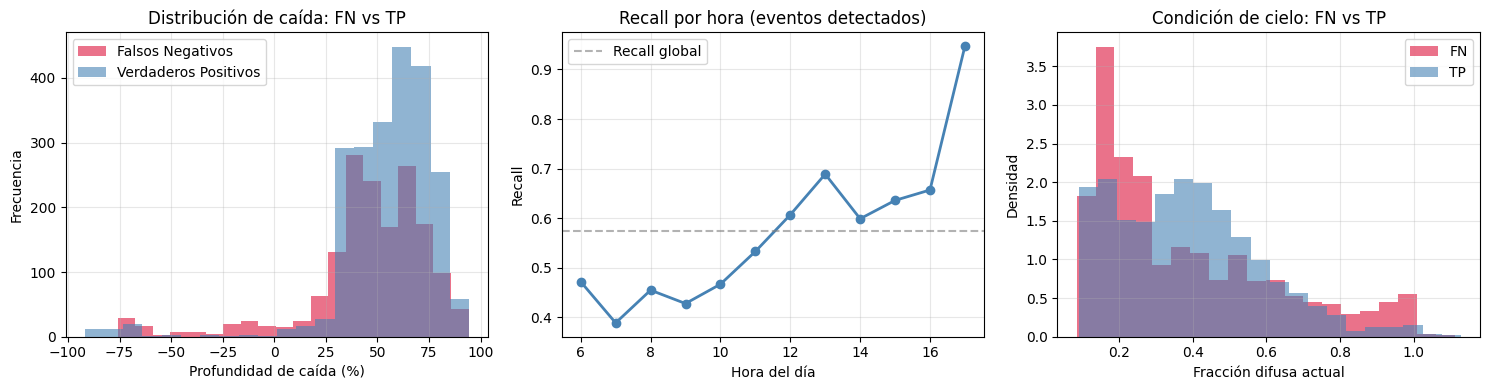


3. SIMULACIÓN DE OPERACIÓN REAL

Periodo simulado: 2020-12-01 → 2021-01-01
Minutos simulados: 17,350

Eventos reales de caída: 855
Alertas emitidas:        845
  → Anticipadas (TP):    437 (51.1% del total)
  → Falsas alarmas (FP): 408  (48.3% de alertas)
Caídas no detectadas:    418 (48.9%)


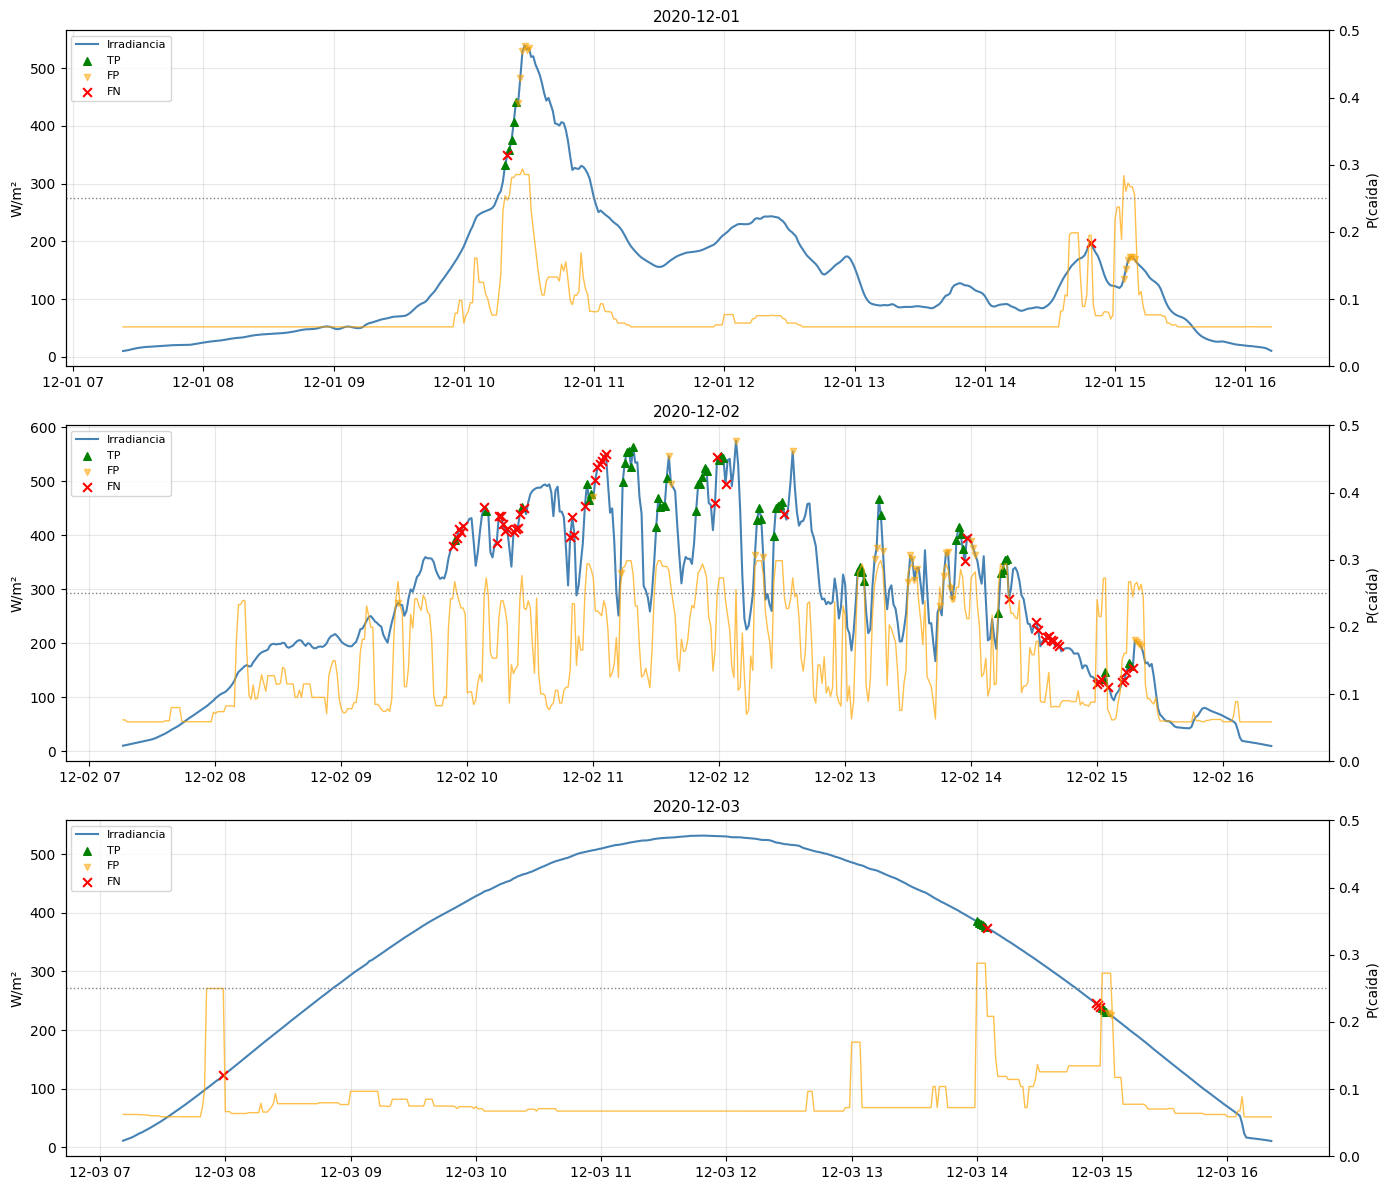


4. TRADUCCIÓN A VALOR ECONÓMICO

Supuestos base:
  Costo por apagón no anticipado: $50
  Costo por falsa alarma (kWh):   $0.05
  Apagones típicos/mes:           40

Resultados modelo (recall=0.575, prec=0.515):
  Apagones anticipados/mes:       23
  Apagones residuales/mes:        17
  Falsas alarmas/mes:             22

  Ahorro bruto/mes:               $1150
  Costo falsas alarmas/mes:       $1.08
  Ahorro neto/mes:                $1149
  Ahorro neto/año:                $13787


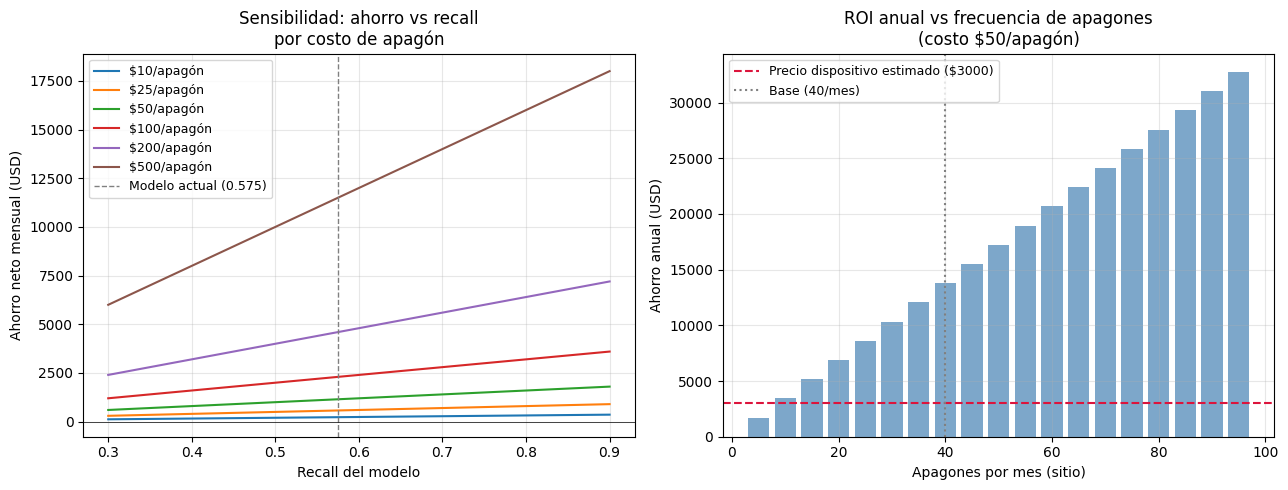


Payback estimado con 40 apagones/mes: 2.6 meses


In [40]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve

# ============================================================
# 1. VALIDACIÓN TEMPORAL CRUZADA
# ============================================================
print("=" * 60)
print("1. VALIDACIÓN TEMPORAL CRUZADA")
print("=" * 60)

tscv = TimeSeriesSplit(n_splits=4, gap=1440)  # gap de 1 día entre splits

base_sorted = base_day.sort_index()
X_all = base_sorted[feature_cols_v2]
y_all = base_sorted['label_30_5min']

cv_results = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]

    if y_tr.sum() < 50 or y_te.sum() < 10:
        print(f"Fold {fold+1} — insuficientes positivos, skip")
        continue

    scale_cv = (len(y_tr) - y_tr.sum()) / y_tr.sum()

    m_cv = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        min_child_samples=30, scale_pos_weight=scale_cv,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1
    )
    X_all = base_sorted[feature_cols_v2].copy()
    X_all.columns = X_all.columns.str.replace(r'[^\w]', '_', regex=True)

    cv_results = []
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all)):
        X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
        ...

    X_all = base_sorted[feature_cols_v2].copy()
    X_all.columns = X_all.columns.str.replace(r'[^\w]', '_', regex=True)
    y_all = base_sorted['label_30_5min']

    cv_results = []
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_all)):
        X_tr, X_te = X_all.iloc[tr_idx], X_all.iloc[te_idx]
        y_tr, y_te = y_all.iloc[tr_idx], y_all.iloc[te_idx]

        if y_tr.sum() < 50 or y_te.sum() < 10:
            print(f"Fold {fold+1} — insuficientes positivos, skip")
            continue

        scale_cv = (len(y_tr) - y_tr.sum()) / y_tr.sum()

        m_cv = lgb.LGBMClassifier(
            n_estimators=300, learning_rate=0.05, num_leaves=63,
            min_child_samples=30, scale_pos_weight=scale_cv,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, verbose=-1
        )

        m_cv.fit(X_tr, y_tr)
        ...
    proba_cv = m_cv.predict_proba(X_te)[:, 1]
    auc_cv   = roc_auc_score(y_te, proba_cv)

    prec_c, rec_c, thresh_c = precision_recall_curve(y_te, proba_cv)
    f1_c  = 2*prec_c*rec_c/(prec_c+rec_c+1e-9)
    best_t = thresh_c[f1_c.argmax()]
    pred_cv = (proba_cv >= best_t).astype(int)

    tp = ((pred_cv==1)&(y_te==1)).sum()
    fn = ((pred_cv==0)&(y_te==1)).sum()
    fp = ((pred_cv==1)&(y_te==0)).sum()
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0

    periodo = f"{X_te.index[0].date()} → {X_te.index[-1].date()}"
    cv_results.append({
        'Fold': fold+1,
        'Periodo test': periodo,
        'Positivos test': int(y_te.sum()),
        'AUC': round(auc_cv, 4),
        'Recall': round(rec, 3),
        'Precision': round(prec, 3),
        'Threshold': round(best_t, 3)
    })
    print(f"Fold {fold+1} | {periodo} | AUC={auc_cv:.4f} | Recall={rec:.3f} | Prec={prec:.3f}")

df_cv = pd.DataFrame(cv_results)
print(f"\nResumen CV:")
print(f"  AUC:       {df_cv['AUC'].mean():.4f} ± {df_cv['AUC'].std():.4f}")
print(f"  Recall:    {df_cv['Recall'].mean():.3f} ± {df_cv['Recall'].std():.3f}")
print(f"  Precision: {df_cv['Precision'].mean():.3f} ± {df_cv['Precision'].std():.3f}")


# ============================================================
# 2. ANÁLISIS DE FALSOS NEGATIVOS POR TIPO DE EVENTO
# ============================================================
print("\n" + "=" * 60)
print("2. ANÁLISIS DE FALSOS NEGATIVOS POR TIPO DE EVENTO")
print("=" * 60)

# Reconstruir predicciones del modelo_5 sobre test
test_fn = test_c.copy()
test_fn['y_true']  = y_test_5.values
test_fn['y_proba'] = y_proba_5
test_fn['y_pred']  = (y_proba_5 >= 0.251).astype(int)

# Velocidad de caída: pendiente de irradiancia en los 10 min previos al evento
test_fn['G_slope_10m_abs'] = test_fn['G_slope_10m'].abs()

# Categorizar en FN vs TP
fn_mask = (test_fn['y_true']==1) & (test_fn['y_pred']==0)
tp_mask = (test_fn['y_true']==1) & (test_fn['y_pred']==1)

fn_df = test_fn[fn_mask]
tp_df = test_fn[tp_mask]

print(f"\nFalsos Negativos: {fn_mask.sum():,}")
print(f"Verdaderos Positivos: {tp_mask.sum():,}")

# Comparar características
for col, name in [
    ('drop_pct_30min',    'Profundidad caída (%)'),
    ('G_slope_10m_abs',   'Velocidad caída (W/m²/min)'),
    ('diffuse_fraction',  'Fracción difusa'),
    ('Tower RH [%]',      'Humedad relativa (%)'),
    ('Broadband Turbidity','Turbidez'),
]:
    if col not in fn_df.columns:
        continue
    fn_mean = fn_df[col].mean()
    tp_mean = tp_df[col].mean()
    print(f"  {name:<30} FN={fn_mean:.2f}  TP={tp_mean:.2f}")

# Velocidad de caída: rápida (<5 min) vs lenta (>15 min)
print(f"\nFN por velocidad de caída (slope):")
fn_rapida = fn_df[fn_df['G_slope_10m_abs'] > 10]
fn_lenta  = fn_df[fn_df['G_slope_10m_abs'] <= 5]
print(f"  Caída rápida (slope>10): {len(fn_rapida):,} ({len(fn_rapida)/len(fn_df)*100:.1f}%)")
print(f"  Caída lenta  (slope≤5):  {len(fn_lenta):,}  ({len(fn_lenta)/len(fn_df)*100:.1f}%)")

print(f"\nFN por hora del día:")
fn_hora = fn_df.groupby(fn_df.index.hour).size()
tp_hora = tp_df.groupby(tp_df.index.hour).size()
recall_hora_fn = (tp_hora / (tp_hora + fn_hora)).round(3).dropna()
print(recall_hora_fn)

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de profundidad de caída
axes[0].hist(fn_df['drop_pct_30min'].dropna(), bins=20, alpha=0.6,
             color='crimson', label='Falsos Negativos')
axes[0].hist(tp_df['drop_pct_30min'].dropna(), bins=20, alpha=0.6,
             color='steelblue', label='Verdaderos Positivos')
axes[0].set_xlabel('Profundidad de caída (%)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de caída: FN vs TP')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Recall por hora
recall_hora_fn.plot(ax=axes[1], marker='o', color='steelblue', lw=2)
axes[1].axhline(0.575, color='gray', linestyle='--', alpha=0.6, label='Recall global')
axes[1].set_xlabel('Hora del día')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall por hora (eventos detectados)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Fracción difusa en FN vs TP
axes[2].hist(fn_df['diffuse_fraction'].dropna(), bins=20, alpha=0.6,
             color='crimson', label='FN', density=True)
axes[2].hist(tp_df['diffuse_fraction'].dropna(), bins=20, alpha=0.6,
             color='steelblue', label='TP', density=True)
axes[2].set_xlabel('Fracción difusa actual')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Condición de cielo: FN vs TP')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fn_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 3. SIMULACIÓN DE OPERACIÓN REAL (pipeline minuto a minuto)
# ============================================================
print("\n" + "=" * 60)
print("3. SIMULACIÓN DE OPERACIÓN REAL")
print("=" * 60)

# Simular el pipeline: el modelo recibe 1 minuto a la vez
# Solo puede usar features disponibles en ese instante
# Features que requieren el futuro (drop_pct, labels) → excluidos
# Features que requieren historia → disponibles si tenemos el buffer

# Usar los últimos 30 días del test como simulación
sim_window = test_c[test_c.index >= '2020-12-01'].copy()
sim_window['y_true']  = y_test_5[sim_window.index]
sim_window['y_proba'] = model_5.predict_proba(sim_window[feature_cols_v2])[:, 1]
sim_window['y_pred']  = (sim_window['y_proba'] >= 0.251).astype(int)
sim_window['alerta']  = (sim_window['y_pred'] == 1)

# Contar alertas y eventos reales
n_alertas  = sim_window['alerta'].sum()
n_eventos  = sim_window['y_true'].sum()
n_detectados = ((sim_window['alerta']==1) & (sim_window['y_true']==1)).sum()
n_falsos   = ((sim_window['alerta']==1) & (sim_window['y_true']==0)).sum()
n_perdidos = ((sim_window['alerta']==0) & (sim_window['y_true']==1)).sum()

print(f"\nPeriodo simulado: {sim_window.index[0].date()} → {sim_window.index[-1].date()}")
print(f"Minutos simulados: {len(sim_window):,}")
print(f"\nEventos reales de caída: {n_eventos}")
print(f"Alertas emitidas:        {n_alertas}")
print(f"  → Anticipadas (TP):    {n_detectados} ({n_detectados/n_eventos*100:.1f}% del total)")
print(f"  → Falsas alarmas (FP): {n_falsos}  ({n_falsos/n_alertas*100:.1f}% de alertas)")
print(f"Caídas no detectadas:    {n_perdidos} ({n_perdidos/n_eventos*100:.1f}%)")

# Visualizar 5 días representativos
dias_con_eventos = sim_window[sim_window['y_true']==1].index.normalize().unique()[:3]

fig, axes = plt.subplots(len(dias_con_eventos), 1,
                          figsize=(14, 4*len(dias_con_eventos)), sharex=False)
if len(dias_con_eventos) == 1:
    axes = [axes]

for ax, dia in zip(axes, dias_con_eventos):
    dia_data = sim_window[sim_window.index.normalize() == dia]
    if len(dia_data) == 0:
        continue

    ax2 = ax.twinx()
    ax.plot(dia_data.index, dia_data['Global CMP22 (vent/cor) [W/m^2]'],
            color='steelblue', lw=1.5, label='Irradiancia')
    ax2.plot(dia_data.index, dia_data['y_proba'],
             color='orange', lw=1, alpha=0.7, label='P(caída)')
    ax2.axhline(0.251, color='gray', linestyle=':', lw=1)

    # Marcar alertas y eventos
    alertas_dia = dia_data[dia_data['alerta']==1]
    eventos_dia = dia_data[dia_data['y_true']==1]
    tp_dia = dia_data[(dia_data['alerta']==1) & (dia_data['y_true']==1)]
    fp_dia = dia_data[(dia_data['alerta']==1) & (dia_data['y_true']==0)]
    fn_dia = dia_data[(dia_data['alerta']==0) & (dia_data['y_true']==1)]

    ax.scatter(tp_dia.index, tp_dia['Global CMP22 (vent/cor) [W/m^2]'],
               color='green', s=30, zorder=5, label='TP', marker='^')
    ax.scatter(fp_dia.index, fp_dia['Global CMP22 (vent/cor) [W/m^2]'],
               color='orange', s=20, zorder=5, label='FP', marker='v', alpha=0.5)
    ax.scatter(fn_dia.index, fn_dia['Global CMP22 (vent/cor) [W/m^2]'],
               color='red', s=40, zorder=5, label='FN', marker='x')

    ax.set_title(f'{dia.date()}', fontsize=11)
    ax.set_ylabel('W/m²'); ax2.set_ylabel('P(caída)')
    ax2.set_ylim(0, 0.5)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('simulacion_operacion.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 4. TRADUCCIÓN A VALOR ECONÓMICO
# ============================================================
print("\n" + "=" * 60)
print("4. TRADUCCIÓN A VALOR ECONÓMICO")
print("=" * 60)

# Parámetros ajustables
costo_apagon_min    = 50     # USD por apagón (pérdida operativa + desgaste)
costo_falsa_alarma  = 0.05   # USD por falsa alarma (kWh de red innecesario)
apagones_mes        = 40     # eventos típicos por mes en sitio solar sin protección
recall              = 0.575
precision           = 0.515
apagones_detectados = apagones_mes * recall
falsas_alarmas_mes  = apagones_detectados / precision * (1 - precision)

ahorro_bruto   = apagones_detectados * costo_apagon_min
costo_fp       = falsas_alarmas_mes * costo_falsa_alarma
ahorro_neto    = ahorro_bruto - costo_fp
apagones_residuales = apagones_mes * (1 - recall)

print(f"\nSupuestos base:")
print(f"  Costo por apagón no anticipado: ${costo_apagon_min}")
print(f"  Costo por falsa alarma (kWh):   ${costo_falsa_alarma}")
print(f"  Apagones típicos/mes:           {apagones_mes}")
print(f"\nResultados modelo (recall={recall}, prec={precision}):")
print(f"  Apagones anticipados/mes:       {apagones_detectados:.0f}")
print(f"  Apagones residuales/mes:        {apagones_residuales:.0f}")
print(f"  Falsas alarmas/mes:             {falsas_alarmas_mes:.0f}")
print(f"\n  Ahorro bruto/mes:               ${ahorro_bruto:.0f}")
print(f"  Costo falsas alarmas/mes:       ${costo_fp:.2f}")
print(f"  Ahorro neto/mes:                ${ahorro_neto:.0f}")
print(f"  Ahorro neto/año:                ${ahorro_neto*12:.0f}")

# Análisis de sensibilidad
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

costos = [10, 25, 50, 100, 200, 500]
recalls_range = np.linspace(0.3, 0.9, 50)

for c in costos:
    ahorros = [apagones_mes * r * c - (apagones_mes * r / precision * (1-precision) * costo_falsa_alarma)
               for r in recalls_range]
    axes[0].plot(recalls_range, ahorros, lw=1.5, label=f'${c}/apagón')

axes[0].axvline(recall, color='gray', linestyle='--', lw=1, label=f'Modelo actual ({recall})')
axes[0].axhline(0, color='black', lw=0.5)
axes[0].set_xlabel('Recall del modelo')
axes[0].set_ylabel('Ahorro neto mensual (USD)')
axes[0].set_title('Sensibilidad: ahorro vs recall\npor costo de apagón')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ROI vs número de apagones por mes
apagones_range = range(5, 100, 5)
roi_data = []
for a in apagones_range:
    an = a * recall * costo_apagon_min - (a*recall/precision*(1-precision)*costo_falsa_alarma)
    roi_data.append(an * 12)  # anual

precio_dispositivo = 3000  # USD estimado hardware + instalación
payback = [precio_dispositivo / (r/12) if r > 0 else np.nan for r in roi_data]

axes[1].bar(apagones_range, roi_data, color='steelblue', alpha=0.7, width=4)
axes[1].axhline(precio_dispositivo, color='crimson', linestyle='--',
                label=f'Precio dispositivo estimado (${precio_dispositivo})')
axes[1].axvline(apagones_mes, color='gray', linestyle=':', label=f'Base ({apagones_mes}/mes)')
axes[1].set_xlabel('Apagones por mes (sitio)')
axes[1].set_ylabel('Ahorro anual (USD)')
axes[1].set_title('ROI anual vs frecuencia de apagones\n(costo $50/apagón)')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('valor_economico.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPayback estimado con {apagones_mes} apagones/mes: {precio_dispositivo/ahorro_neto:.1f} meses")